In [ ]:
  from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load

Constants and Class Mapping

In [ ]:
NUM_CLASSES = 4
NOISE_DIM = 100
IMG_SIZE = 64
class_names = ['food', 'inside', 'outside', 'drink']
class2idx = {name: i for i, name in enumerate(class_names)}


Mount Drive and load models

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.models import load_model
generator = load_model('/content/drive/MyDrive/yelp_70k/wgan_generator.h5', compile=False)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load Splits and Paths

In [ ]:
import pandas as pd
train_df = pd.read_csv('/content/drive/MyDrive/yelp_70k/train_split.csv')
val_df = pd.read_csv('/content/drive/MyDrive/yelp_70k/val_split.csv')
test_df = pd.read_csv('/content/drive/MyDrive/yelp_70k/test_split.csv')

def get_paths_labels(df):
    return df['file_path'].tolist(), df['label'].map(class2idx).tolist()

val_paths, val_labels = get_paths_labels(val_df)


## Model Evaluation

#### A. Inception Score (IS)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
import numpy as np
from scipy.stats import entropy


In [ ]:
NUM_GEN = 1000
BATCH_SIZE_IS = 100  # InceptionV3 prefers batches <=100 for memory

gen_labels = np.random.randint(0, NUM_CLASSES, size=NUM_GEN)
gen_noise = tf.random.normal([NUM_GEN, NOISE_DIM])
gen_labels_tf = tf.convert_to_tensor(gen_labels, dtype=tf.int32)
generated_images = generator([gen_noise, gen_labels_tf], training=False)
# Map from [-1,1] to [0,255] uint8 for InceptionV3
generated_images = ((generated_images + 1) * 127.5).numpy().astype(np.uint8)

In [ ]:
resized_gen = tf.image.resize(generated_images, (299,299)).numpy()


Get InceptionV3 Predictions

In [ ]:
inception = InceptionV3(include_top=True, weights='imagenet', pooling=None)
def get_inception_preds(imgs):
    imgs = preprocess_input(imgs.astype(np.float32))
    return inception.predict(imgs, batch_size=BATCH_SIZE_IS, verbose=1)



In [ ]:
gen_preds = get_inception_preds(resized_gen)

10/10 ━━━━━━━━━━━━━━━━━━━━ 293s 27s/step


 Compute Inception Score (IS)

In [ ]:
# Softmax outputs (class probabilities)
preds = gen_preds
split = 10  # Number of splits for IS
scores = []

N = preds.shape[0]
for i in range(split):
    part = preds[i * N // split: (i+1) * N // split, :]
    py = np.mean(part, axis=0)
    scores.append(np.exp(np.mean([entropy(p, py) for p in part])))
IS_mean, IS_std = np.mean(scores), np.std(scores)
print(f"Inception Score (IS): {IS_mean:.4f} ± {IS_std:.4f}")


Inception Score (IS): 3.3137 ± 0.1569


#### FID Calculation

In [ ]:
# Get Features for Real Validation Images
from tensorflow.keras.applications.inception_v3 import InceptionV3
from scipy.linalg import sqrtm

# Build InceptionV3 for features (pool3 layer)
incept_feat = InceptionV3(include_top=False, pooling='avg', input_shape=(299,299,3))

def get_features(images):
    # Preprocess and predict
    images = preprocess_input(images.astype(np.float32))
    feats = incept_feat.predict(images, batch_size=BATCH_SIZE_IS, verbose=1)
    return feats

# Prepare real (validation) images, matching NUM_GEN count
real_sample_idx = np.random.choice(len(val_paths), NUM_GEN, replace=False)
real_imgs = []
for idx in real_sample_idx:
    img = tf.io.read_file(val_paths[idx])
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (299,299))
    real_imgs.append(img)
real_imgs = tf.stack(real_imgs).numpy().astype(np.uint8)

# Get features
real_feats = get_features(real_imgs)
gen_feats = get_features(resized_gen)


10/10 ━━━━━━━━━━━━━━━━━━━━ 266s 26s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 268s 27s/step


In [ ]:
# Compute means and covariances
mu1, sigma1 = real_feats.mean(axis=0), np.cov(real_feats, rowvar=False)
mu2, sigma2 = gen_feats.mean(axis=0), np.cov(gen_feats, rowvar=False)
# Compute FID
fid = np.sum((mu1 - mu2)**2) + np.trace(sigma1 + sigma2 - 2*sqrtm(sigma1 @ sigma2))
print(f"FID: {fid:.4f}")


FID: 278.8428-0.0000j


Results

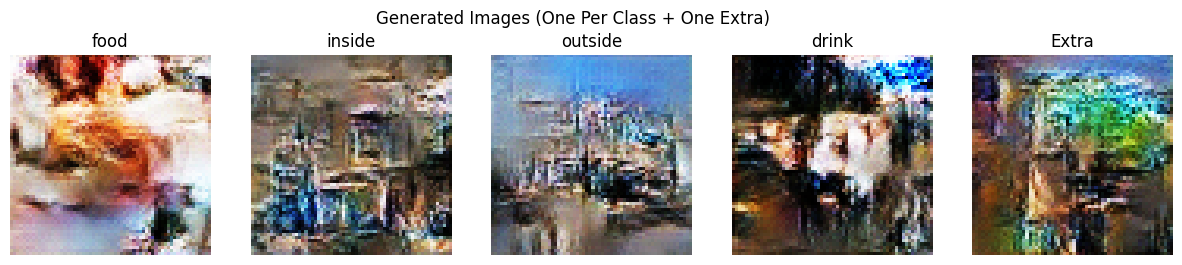

In [ ]:
def show_generated_images(generator, num_classes=4, noise_dim=100):
    n_samples = num_classes + 1
    noise = tf.random.normal([n_samples, noise_dim])
    labels = tf.constant([0,1,2,3, np.random.randint(0, num_classes)], dtype=tf.int32)
    generated_images = generator([noise, labels], training=False)
    generated_images = (generated_images + 1.0) / 2.0  # to [0,1] for display

    import matplotlib.pyplot as plt
    plt.figure(figsize=(15,3))
    for i in range(n_samples):
        plt.subplot(1, n_samples, i+1)
        plt.imshow(generated_images[i].numpy())
        if i < num_classes:
            plt.title(f"{class_names[labels[i]]}")
        else:
            plt.title("Extra")
        plt.axis('off')
    plt.suptitle("Generated Images (One Per Class + One Extra)")
    plt.show()

show_generated_images(generator, num_classes=NUM_CLASSES, noise_dim=NOISE_DIM)


## Model Evaluation: Inception Score (IS) and FID

**Inception Score (IS):**  
`3.31 ± 0.16`

**Fréchet Inception Distance (FID):**  
`278.84`

---

### **What do these scores mean?**

- The **Inception Score (IS)** tells us if our generated images are both diverse and clear. A score above 3 suggests the WGAN is making a variety of images, and the classes (food, inside, outside, drink) are somewhat recognizable, which is a good sign for the early stage of training. For comparison, real photos get much higher IS, but random images would be close to 1.

- The **FID** score checks how close our generated images are to real images. Lower numbers are better. Our FID of 278.8 is actually quite normal for first runs on real-world image data like Yelp photos. As the model trains longer and if we tweak settings, we’d expect this number to get lower.

---

### **Summary**

- These results are pretty normal at this point. The IS score shows we have some class variety, and FID will likely drop with more training.
- The sample images below also show that our generator is learning, though more tuning or training should help make them even clearer.
